    Age  Gender  Weight (kg)  Height (m) Max_BPM  Avg_BPM  Resting_BPM  \
0  34.0  Female         86.7        1.86     174    152.0         74.0   
1  26.0  Female         84.7        1.83     166    156.0         73.0   
2  22.0    Male         64.8        1.85     187    166.0         64.0   
3  54.0  Female         75.3        1.82     187    169.0         58.0   
4  34.0  Female         52.8        1.74     177    169.0         66.0   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.12            712.0     Strength            12.8   
1                      1.00            833.0     Strength            27.9   
2                      1.24           1678.0       Cardio            28.7   
3                      1.45            628.0       Cardio            31.8   
4                      1.60           1286.0     Strength            26.4   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0              

/tmp/ipykernel_15231/1129364495.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_life["smokes"] = df_life["smokes"].replace({"yes": 1, "no": 0, "1": 1, "0": 0})


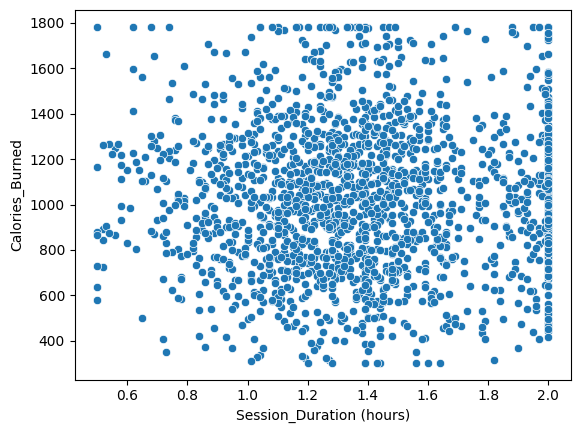

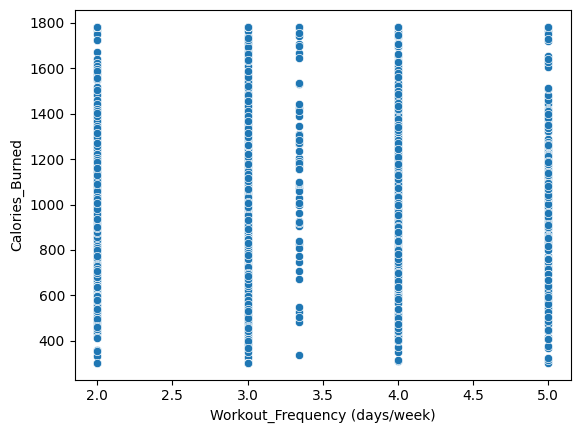

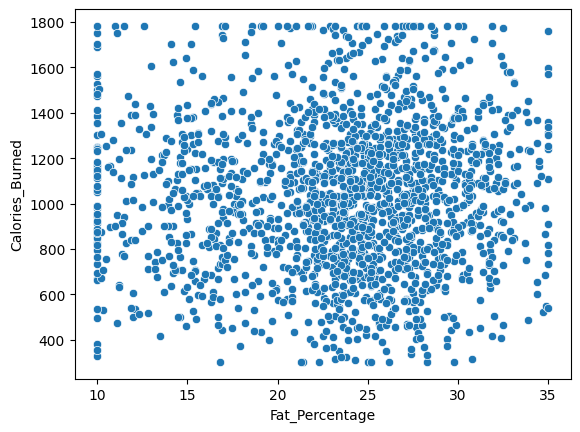

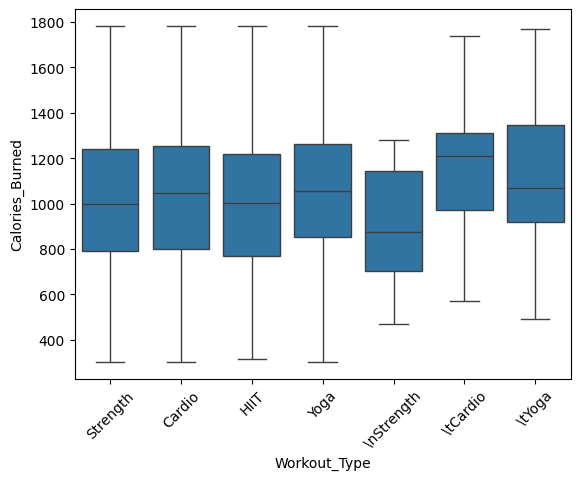

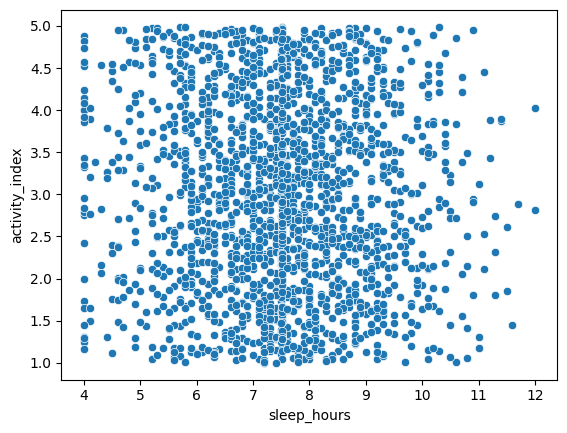

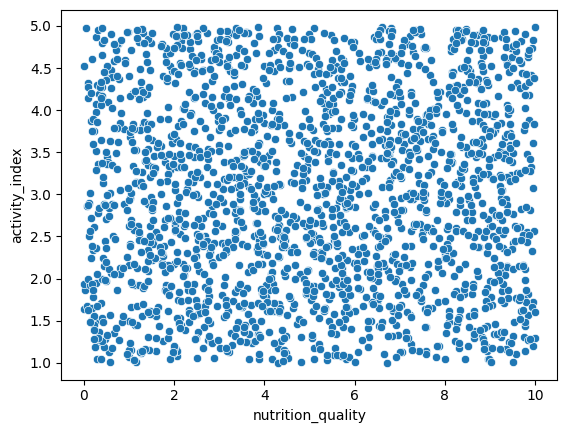

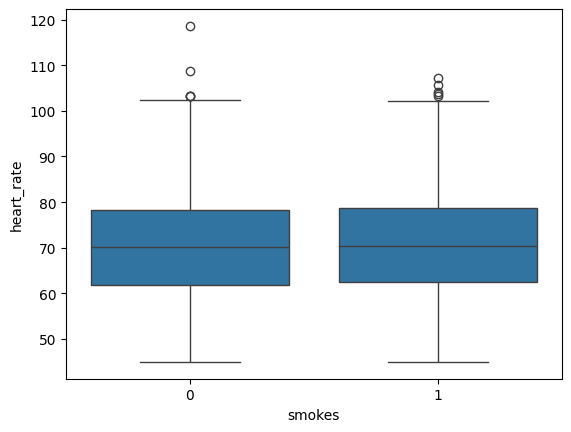

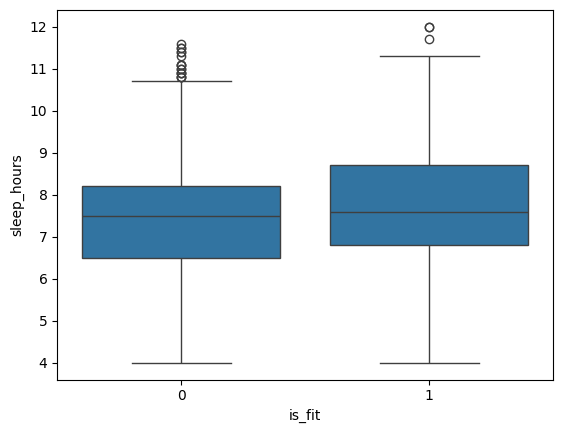

T-test for workout frequency vs calories burned:
TtestResult(statistic=np.float64(-0.8099353124744239), pvalue=np.float64(0.41808453191181627), df=np.float64(1798.0))

T-test for fitness status vs sleep hours:
TtestResult(statistic=np.float64(4.699971589322007), pvalue=np.float64(2.779544376312277e-06), df=np.float64(1998.0))

T-test for smoking status vs heart rate:
TtestResult(statistic=np.float64(0.4372233049268743), pvalue=np.float64(0.6619966616725126), df=np.float64(1998.0))

ANOVA for workout type vs calories burned:
F_onewayResult(statistic=np.float64(2.063195333894718), pvalue=np.float64(0.0545934281038816))


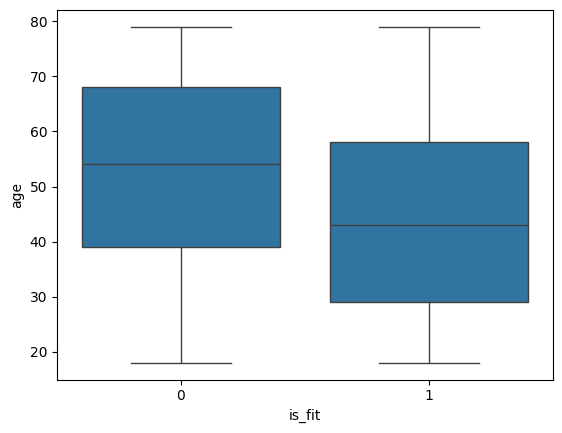

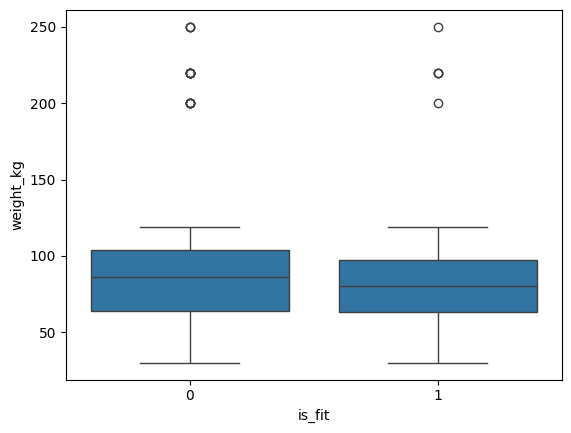

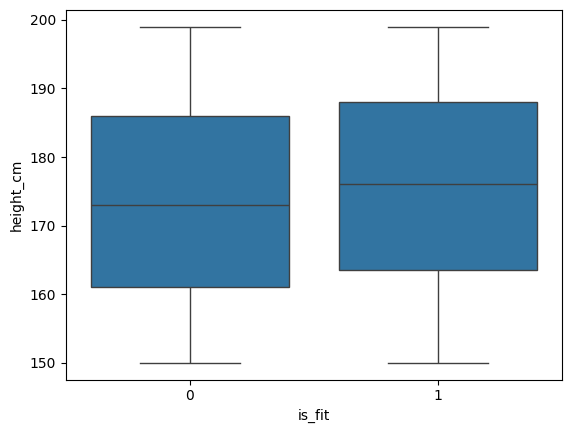

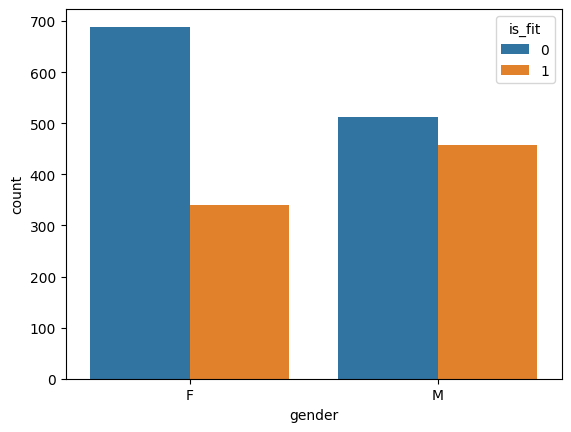

T-test for fitness status vs age:
TtestResult(statistic=np.float64(-9.792534593044591), pvalue=np.float64(3.7841094362539743e-22), df=np.float64(1998.0))
T-test for fitness status vs weight:
TtestResult(statistic=np.float64(-3.950302958591027), pvalue=np.float64(8.07614396508611e-05), df=np.float64(1998.0))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_fit = pd.read_csv("gym_members_exercise_tracking_synthetic_data.csv")
df_life = pd.read_csv("fitness_dataset.csv")
print(df_fit.head())
print(df_life.head())
print(df_fit.columns.tolist())
print(df_life.columns.tolist())
print(df_fit.isnull().sum())
print()
print(df_life.isnull().sum())

df_life["sleep_hours"] = df_life["sleep_hours"].fillna(df_life["sleep_hours"].mean())
df_life["smokes"] = df_life["smokes"].replace({"yes": 1, "no": 0, "1": 1, "0": 0})
df_life["smokes"] = df_life["smokes"].astype(int)
print(df_life["smokes"].unique())
print(df_life["sleep_hours"].isnull().sum())

df_fit_use = df_fit[["Session_Duration (hours)", "Calories_Burned", "Workout_Type", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]].copy()
df_life_use = df_life[["age", "gender", "height_cm", "weight_kg", "sleep_hours", "nutrition_quality", "activity_index", "heart_rate", "blood_pressure", "smokes", "is_fit"]].copy()

print(df_fit_use.head())
print(df_life_use.head())
print(df_fit_use.shape)
print(df_life_use.shape)
print()
print(df_fit_use.isnull().sum())
print()
print(df_life_use.isnull().sum())

df_fit_use["Session_Duration (hours)"] = df_fit_use["Session_Duration (hours)"].fillna(df_fit_use["Session_Duration (hours)"].mean())
df_fit_use["Calories_Burned"] = df_fit_use["Calories_Burned"].fillna(df_fit_use["Calories_Burned"].mean())
df_fit_use["Fat_Percentage"] = df_fit_use["Fat_Percentage"].fillna(df_fit_use["Fat_Percentage"].mean())
df_fit_use["Water_Intake (liters)"] = df_fit_use["Water_Intake (liters)"].fillna(df_fit_use["Water_Intake (liters)"].mean())
df_fit_use["Workout_Frequency (days/week)"] = df_fit_use["Workout_Frequency (days/week)"].fillna(df_fit_use["Workout_Frequency (days/week)"].mean())
df_fit_use["BMI"] = df_fit_use["BMI"].fillna(df_fit_use["BMI"].mean())
df_fit_use["Workout_Type"] = df_fit_use["Workout_Type"].fillna(df_fit_use["Workout_Type"].mode()[0])
df_fit_use["Experience_Level"] = df_fit_use["Experience_Level"].fillna(df_fit_use["Experience_Level"].mode()[0])

print("Fitness dataset missing values after cleaning:")
print(df_fit_use.isnull().sum())
print()
print("Lifestyle dataset missing values after cleaning:")
print(df_life_use.isnull().sum())

sns.scatterplot(x="Session_Duration (hours)", y="Calories_Burned", data=df_fit_use)
plt.show()

sns.scatterplot(x="Workout_Frequency (days/week)", y="Calories_Burned", data=df_fit_use)
plt.show()

sns.scatterplot(x="Fat_Percentage", y="Calories_Burned", data=df_fit_use)
plt.show()

sns.boxplot(x="Workout_Type", y="Calories_Burned", data=df_fit_use)
plt.xticks(rotation=45)
plt.show()

sns.scatterplot(x="sleep_hours", y="activity_index", data=df_life_use)
plt.show()

sns.scatterplot(x="nutrition_quality", y="activity_index", data=df_life_use)
plt.show()

sns.boxplot(x="smokes", y="heart_rate", data=df_life_use)
plt.show()

sns.boxplot(x="is_fit", y="sleep_hours", data=df_life_use)
plt.show()

from scipy.stats import ttest_ind, f_oneway

high_freq = df_fit_use[df_fit_use["Workout_Frequency (days/week)"] > 4]["Calories_Burned"]
low_freq = df_fit_use[df_fit_use["Workout_Frequency (days/week)"] <= 4]["Calories_Burned"]
print("T-test for workout frequency vs calories burned:")
print(ttest_ind(high_freq, low_freq))

fit_group = df_life_use[df_life_use["is_fit"] == 1]["sleep_hours"]
nonfit_group = df_life_use[df_life_use["is_fit"] == 0]["sleep_hours"]
print("\nT-test for fitness status vs sleep hours:")
print(ttest_ind(fit_group, nonfit_group))

smoke_group = df_life_use[df_life_use["smokes"] == 1]["heart_rate"]
nonsmoke_group = df_life_use[df_life_use["smokes"] == 0]["heart_rate"]
print("\nT-test for smoking status vs heart rate:")
print(ttest_ind(smoke_group, nonsmoke_group))

groups = [group["Calories_Burned"].dropna() for _, group in df_fit_use.groupby("Workout_Type")]
print("\nANOVA for workout type vs calories burned:")
print(f_oneway(*groups))

sns.boxplot(x="is_fit",y="age",data=df_life_use)
plt.show()

sns.boxplot(x="is_fit",y="weight_kg",data=df_life_use)
plt.show()

sns.boxplot(x="is_fit",y="height_cm",data=df_life_use)
plt.show()

sns.countplot(x="gender",hue="is_fit",data=df_life_use)
plt.show()

from scipy.stats import ttest_ind

fit_age=df_life_use[df_life_use["is_fit"]==1]["age"]
nonfit_age=df_life_use[df_life_use["is_fit"]==0]["age"]
print("T-test for fitness status vs age:")
print(ttest_ind(fit_age,nonfit_age))

fit_weight=df_life_use[df_life_use["is_fit"]==1]["weight_kg"]
nonfit_weight=df_life_use[df_life_use["is_fit"]==0]["weight_kg"]
print("T-test for fitness status vs weight:")
print(ttest_ind(fit_weight,nonfit_weight))

# Hypothesis test summary:
# Workout frequency vs calories burned: p = 0.4181 -> not significant
# Fitness status vs sleep hours: p = 2.78e-06 -> significant
# Smoking status vs heart rate: p = 0.6620 -> not significant
# Workout type vs calories burned: p = 0.0546 -> not significant at 0.05 level
# Fitness status vs age: p = 3.78e-22 -> significant
# Fitness status vs weight: p = 8.08e-05 -> significant
